# Libraries

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the data + printing

In [23]:
Data = pd.read_csv('DataSets/IRIS.csv',delimiter=',')
print(Data)

     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


# The models

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn . model_selection import train_test_split

X=Data.values[:,0:-1]
y=Data.values[:,-1]

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2 )

gini_model = DecisionTreeClassifier(criterion='gini', random_state=42)
gini_model.fit(X_train,y_train)

info_gain_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
info_gain_model.fit(X_train,y_train)



DecisionTreeClassifier(criterion='entropy', random_state=42)

In [25]:
tree_ = gini_model.tree_
n_nodes = tree_.node_count
print(f"Number of nodes: {n_nodes}")
# Example: Iterating through nodes to get properties
for i in range(n_nodes):
    if tree_.children_left[i] != tree_.children_right[i]:  # Internal node
        print(f"Node {i}: Split on feature {tree_.feature[i]} <= {tree_.threshold[i]:.2f}")
    else:  # Leaf node
        print(f"Node {i}: Leaf node with impurity {tree_.impurity[i]:.2f}")
        

Number of nodes: 11
Node 0: Split on feature 2 <= 2.45
Node 1: Leaf node with impurity 0.00
Node 2: Split on feature 2 <= 4.75
Node 3: Leaf node with impurity 0.00
Node 4: Split on feature 2 <= 4.95
Node 5: Split on feature 1 <= 3.05
Node 6: Split on feature 1 <= 2.60
Node 7: Leaf node with impurity 0.00
Node 8: Leaf node with impurity 0.00
Node 9: Leaf node with impurity 0.00
Node 10: Leaf node with impurity 0.00


In [26]:
tree_ = info_gain_model.tree_
n_nodes = tree_.node_count
print(f"Number of nodes: {n_nodes}")
# Example: Iterating through nodes to get properties
for i in range(n_nodes):
    if tree_.children_left[i] != tree_.children_right[i]:  # Internal node
        print(f"Node {i}: Split on feature {tree_.feature[i]} <= {tree_.threshold[i]:.2f}")
    else:  # Leaf node
        print(f"Node {i}: Leaf node with impurity {tree_.impurity[i]:.2f}")

Number of nodes: 11
Node 0: Split on feature 2 <= 2.45
Node 1: Leaf node with impurity 0.00
Node 2: Split on feature 2 <= 4.75
Node 3: Leaf node with impurity 0.00
Node 4: Split on feature 2 <= 4.95
Node 5: Split on feature 1 <= 3.05
Node 6: Split on feature 1 <= 2.60
Node 7: Leaf node with impurity 0.00
Node 8: Leaf node with impurity 0.00
Node 9: Leaf node with impurity 0.00
Node 10: Leaf node with impurity 0.00


# Comparing the models

In [27]:
print(" ---Gini index model :")
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = gini_model , X = X_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

print("\n ---Information Gain model :")
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = info_gain_model , X = X_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

 ---Gini index model :
Accuracy :  95.0000 %
Standard Deviation : 4.0825 %

 ---Information Gain model :
Accuracy :  95.8333 %
Standard Deviation : 4.1667 %


# Visualizing the results

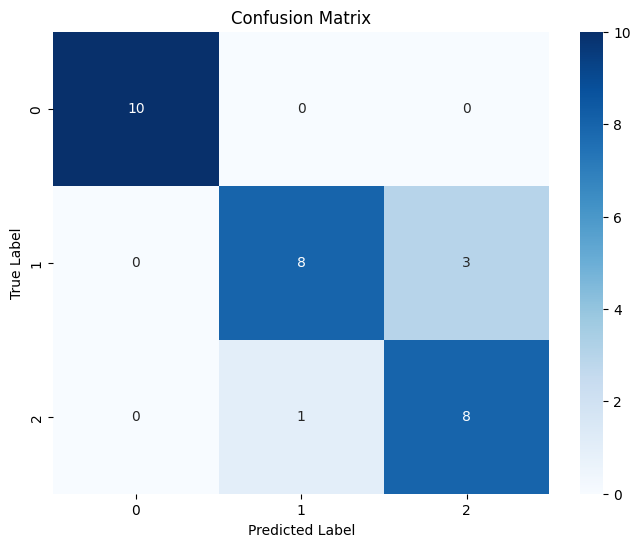

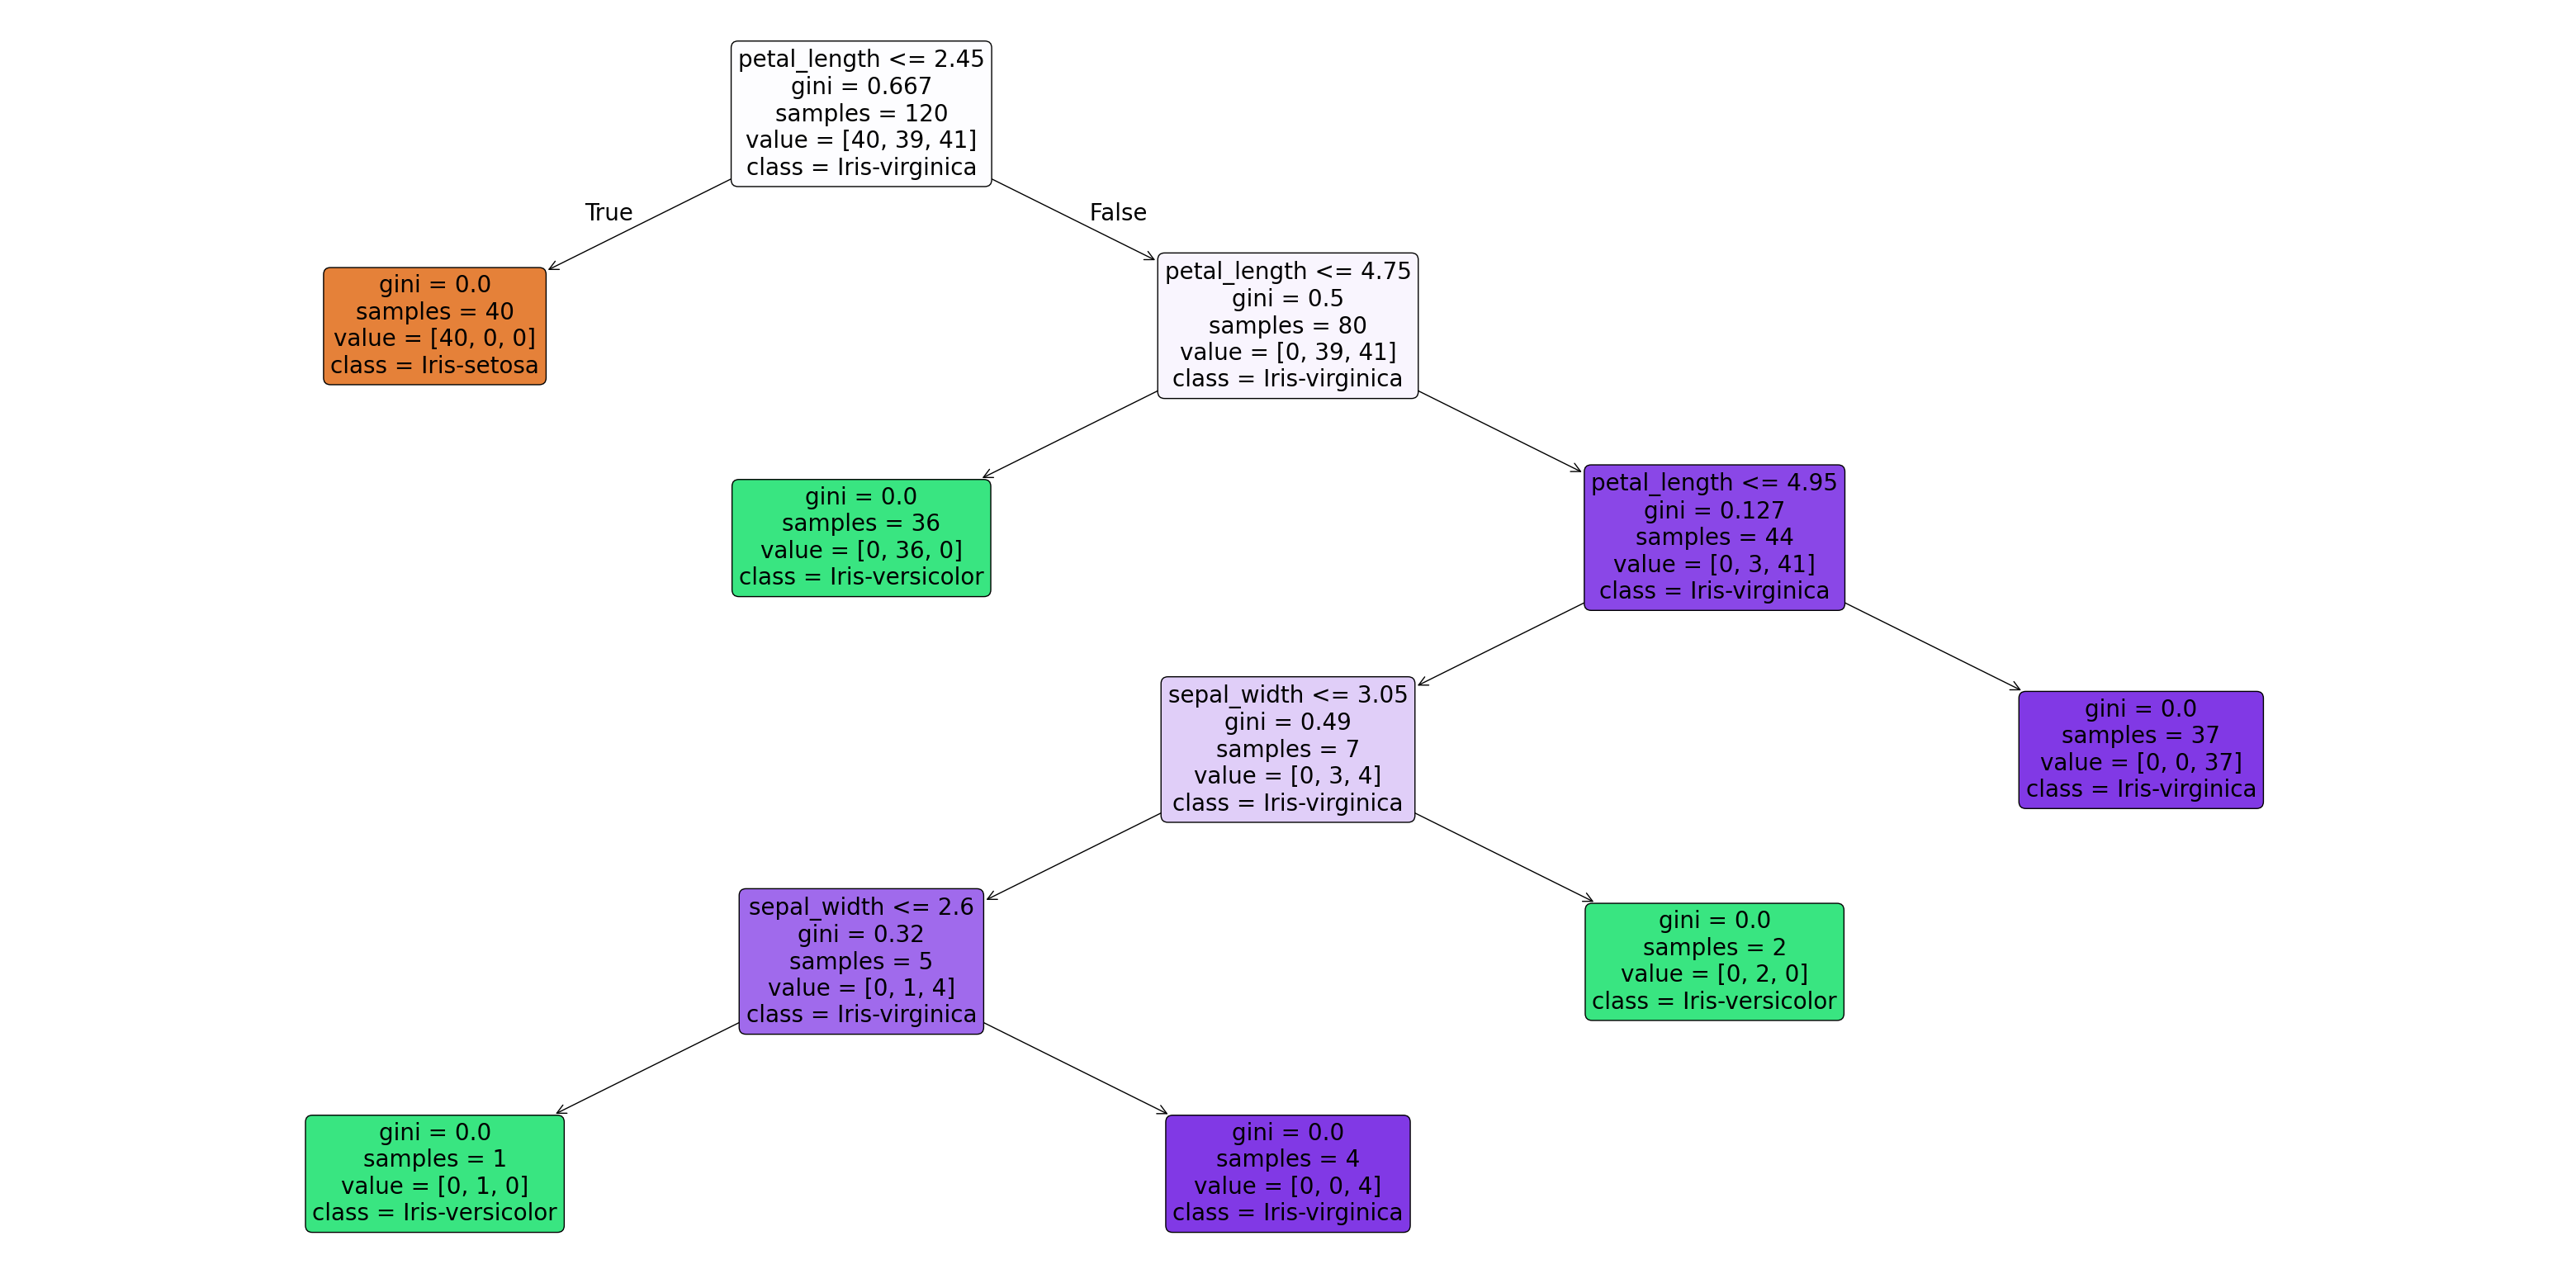

In [30]:
from sklearn . metrics import confusion_matrix
import seaborn as sns

from sklearn. tree import plot_tree

y_pred = gini_model.predict(X_test)
cm = confusion_matrix ( y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


plt.figure(figsize =(40,20))
plot_tree(gini_model, filled=True, feature_names=Data.columns[0:-1], class_names=Data['species'].unique(), rounded=True, fontsize=20)
plt.show()


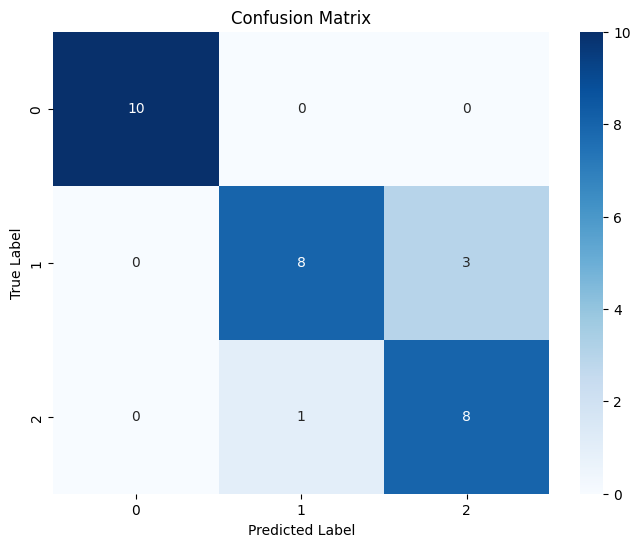

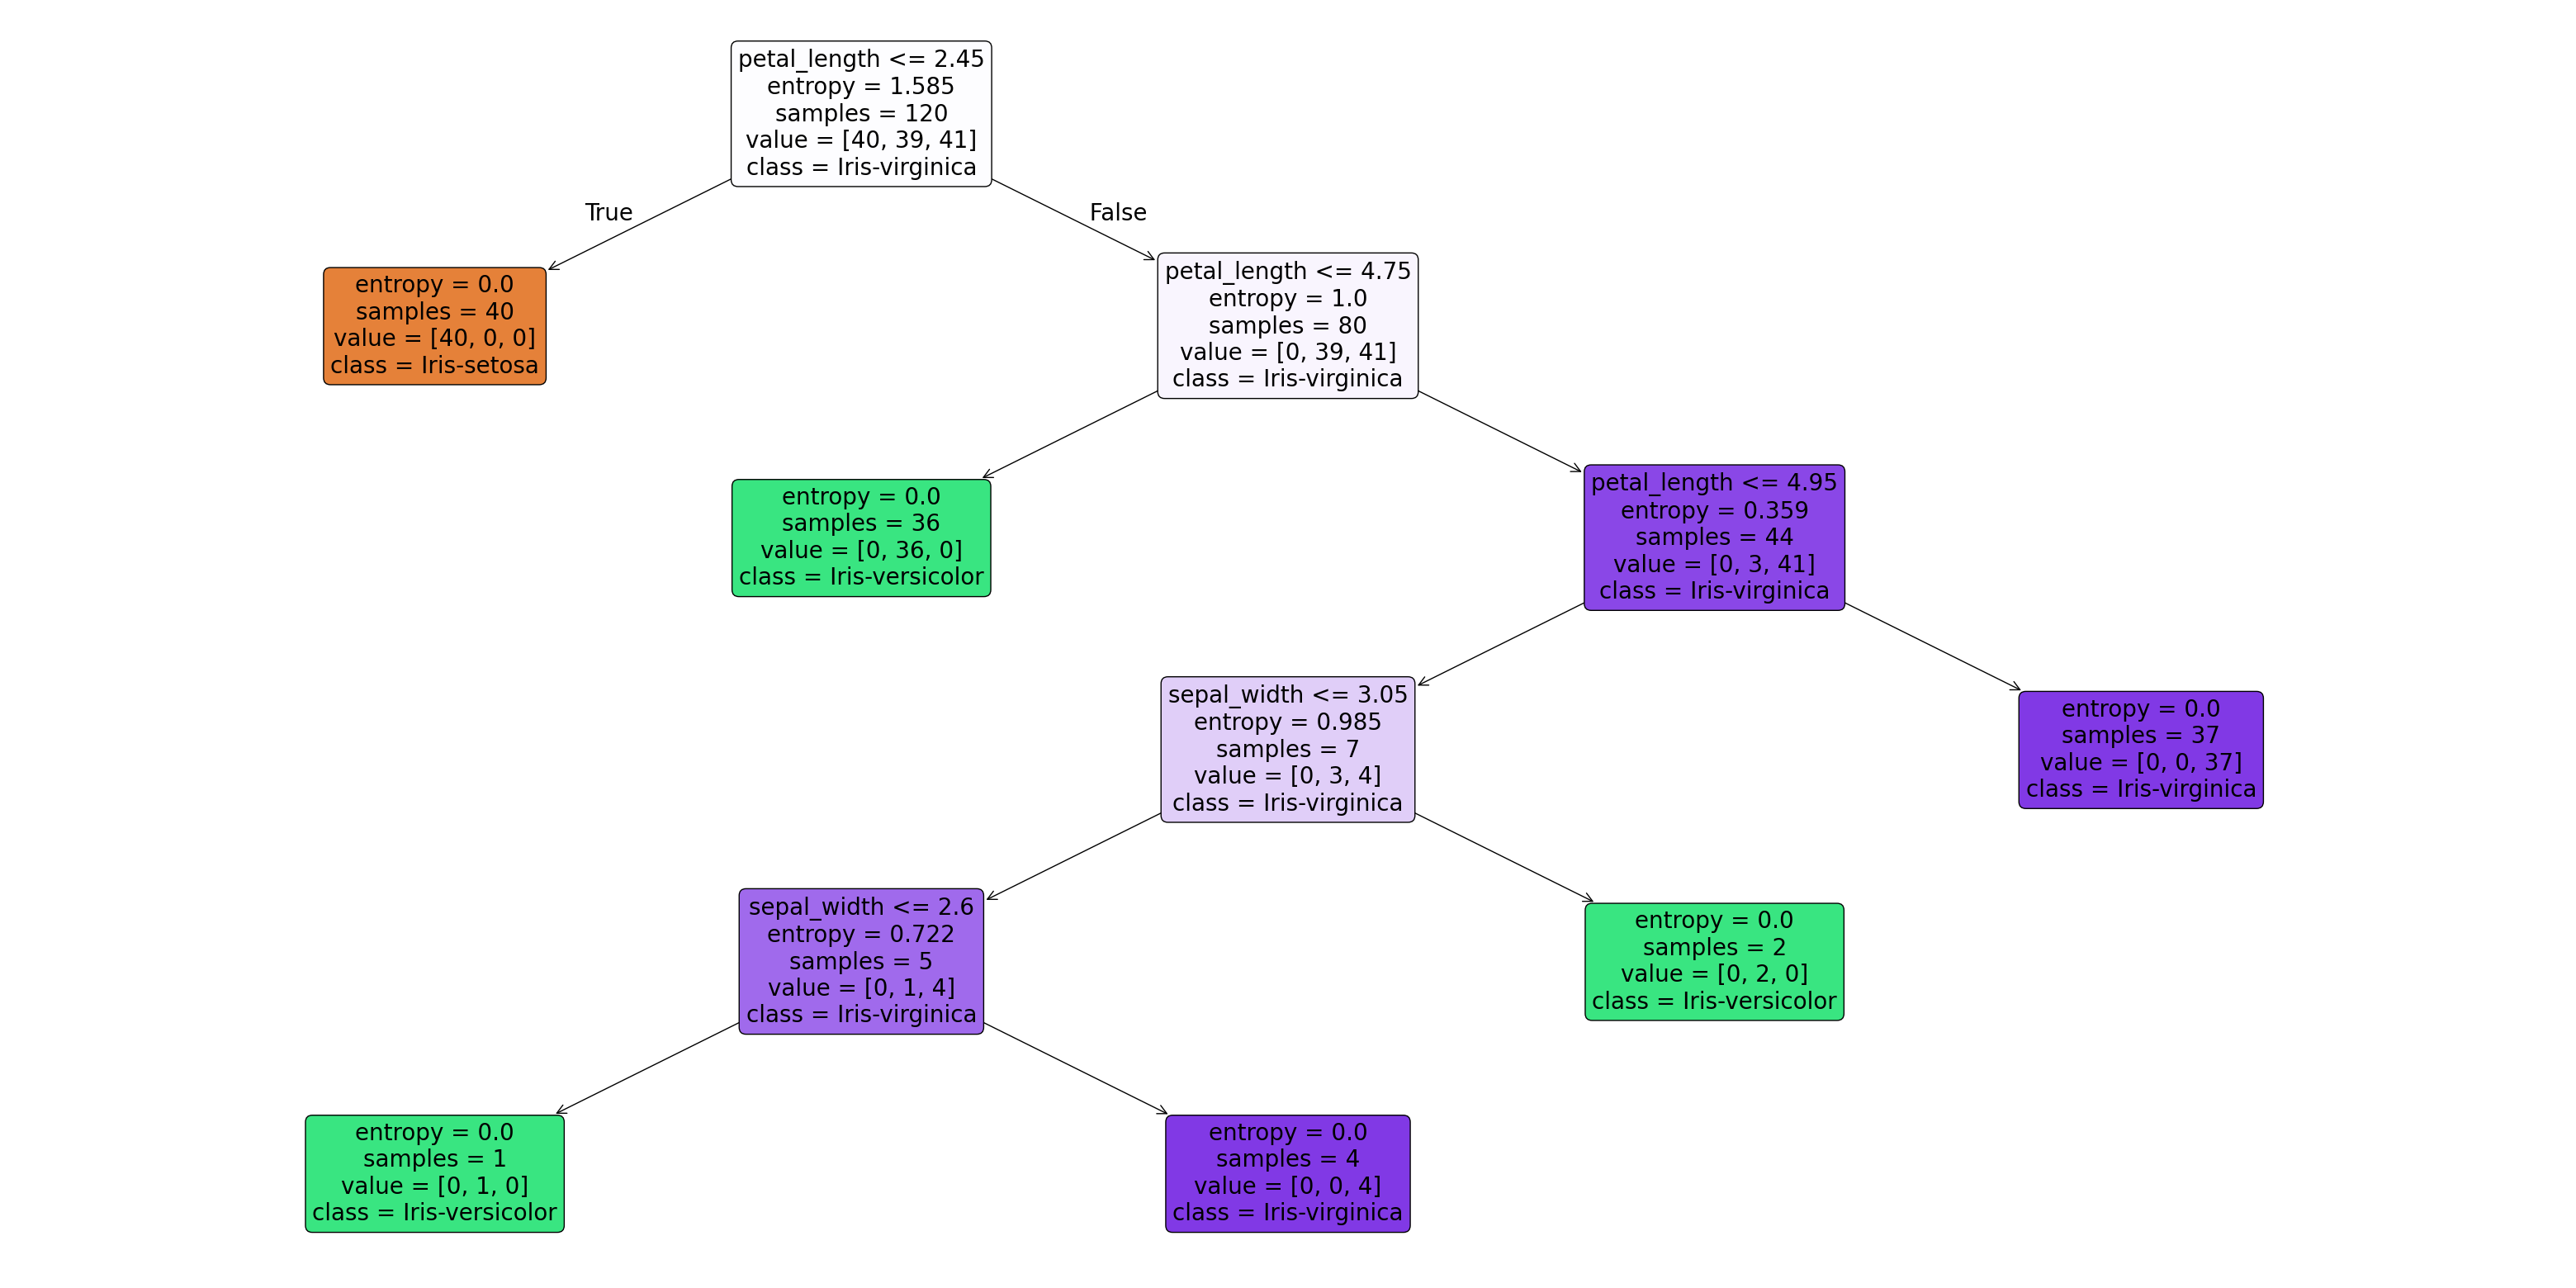

In [31]:
y_pred = info_gain_model.predict(X_test)
cm = confusion_matrix ( y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize =(8,6))
sns.heatmap(cm,annot = True, fmt='d', cmap ='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize =(40,20))
plot_tree(info_gain_model, filled=True, feature_names=Data.columns[0:-1], class_names=Data['species'].unique(), rounded=True, fontsize=20)
plt.show()
